# Phân loại Cảm xúc Đánh giá Phim bằng Spark MLlib
*Sử dụng Thuật toán Hồi quy Logistic (Logistic Regression) & TF-IDF*

# import các thư viện quan trọng

In [ ]:
import os
import sys
from pyspark.sql import functions as F
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from datetime import datetime
from datasets import load_dataset

current_dir = os.path.abspath('')
project_root = os.path.abspath(os.path.join(current_dir, '../..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from transformation.common.spark_utils import get_spark_session, write_data_to_minio, get_layer_path

d:\hoc tap\ki 6\DoAnNganh\final_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Lấy dữ liệu trên minio

In [3]:
spark = get_spark_session("SparkML_Pipeline")

In [4]:
endpoint_url = os.getenv("ENDPOINT_URL")
key = os.getenv("MINIO_ROOT_USER")
secret = os.getenv("MINIO_ROOT_PASSWORD")

In [5]:
def load_data_for_nlp(s3a_path):
    print(f"[*] Đang kết nối tới MinIO tại {endpoint_url}...")
    print(f"[*] Nạp dữ liệu từ: {s3a_path}")
    try:
        df = spark.read.parquet(s3a_path)
        return df
    except Exception as e:
        print(f"[!] Lỗi khi nạp dữ liệu trực tiếp: {e}")
        return None

In [ ]:
# path = os.path.abspath(os.path.join(os.path.dirname(__file__), "../.."))
# print(path)
bucket_name = "silver"
base_prefix = "nlp/dataset"
target_date = datetime.now()
s3_path = get_layer_path("s3a://", bucket_name, base_prefix, target_date) 
print(s3_path)
df = load_data_for_nlp(s3_path + "*.parquet")

s3a://silver/nlp/dataset/2026/03/30/
[*] Đang kết nối tới MinIO tại http://localhost:9000...
[*] Nạp dữ liệu từ: s3a://silver/nlp/dataset/2026/03/30/*.parquet


In [7]:
df.show(5)

+--------------------+----------+--------------------+------+-------------+
|           review_id|   imdb_id|             content|rating|source_system|
+--------------------+----------+--------------------+------+-------------+
|000524abf6de59d91...|tt27543632|For the first hou...|   7.0|         imdb|
|000a465558f22ae39...| tt7181546|I actual like thi...|   7.0|         imdb|
|002c15fdae45738c4...|tt15239678|This movie is a s...|   9.0|         imdb|
|00356c43c1324f1f6...|tt15940132|This is the secon...|   3.0|         imdb|
|00448ca2411ce6bb9...|tt30144839|Horrible from sta...|   2.0|         imdb|
+--------------------+----------+--------------------+------+-------------+
only showing top 5 rows


# Tiền xử lý dữ liệu

In [8]:
print("kiểm tra các trường dữ liệu")
print(f"Tổng số bản ghi ban đầu: {df.count()}")
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

kiểm tra các trường dữ liệu
Tổng số bản ghi ban đầu: 70078
+---------+-------+-------+------+-------------+
|review_id|imdb_id|content|rating|source_system|
+---------+-------+-------+------+-------------+
|        0|      0|      0|  2275|            0|
+---------+-------+-------+------+-------------+



# Xử lý các trường dữ liệu thiếu

In [9]:
print("Top các phim có nhiều review bị thiếu rating nhất")
null_ratings_df = df.filter(F.col("rating").isNull())

null_ratings_df.groupBy("source_system", "imdb_id") \
               .count() \
               .orderBy(F.desc("count")) \
               .show(10)

print("\n🔍 2. KIỂM TRA NGUỒN: Lỗi này do IMDB hay TMDB")
null_ratings_df.groupBy("source_system").count().show()

Top các phim có nhiều review bị thiếu rating nhất
+-------------+----------+-----+
|source_system|   imdb_id|count|
+-------------+----------+-----+
|         imdb| tt0241527|  332|
|         imdb| tt0088763|  169|
|         imdb| tt0120737|  143|
|         imdb| tt0092099|  101|
|         imdb| tt0407887|   89|
|         imdb| tt3659388|   67|
|         imdb| tt0468569|   67|
|         imdb| tt0118615|   66|
|         imdb|tt26581740|   57|
|         imdb|tt31193180|   54|
+-------------+----------+-----+
only showing top 10 rows

🔍 2. KIỂM TRA NGUỒN: Lỗi này do IMDB hay TMDB
+-------------+-----+
|source_system|count|
+-------------+-----+
|         tmdb|    6|
|         imdb| 2269|
+-------------+-----+



# Gán nhãn nhãn dữ liệu

In [10]:
# Tạo label: >= 7 là 1.0 (Positive), < 7 là 0.0 (Negative)
df = df.withColumn("label", F.when(F.col("rating") >= 7, 1.0).otherwise(0.0))
df.show(5)

+--------------------+----------+--------------------+------+-------------+-----+
|           review_id|   imdb_id|             content|rating|source_system|label|
+--------------------+----------+--------------------+------+-------------+-----+
|000524abf6de59d91...|tt27543632|For the first hou...|   7.0|         imdb|  1.0|
|000a465558f22ae39...| tt7181546|I actual like thi...|   7.0|         imdb|  1.0|
|002c15fdae45738c4...|tt15239678|This movie is a s...|   9.0|         imdb|  1.0|
|00356c43c1324f1f6...|tt15940132|This is the secon...|   3.0|         imdb|  0.0|
|00448ca2411ce6bb9...|tt30144839|Horrible from sta...|   2.0|         imdb|  0.0|
+--------------------+----------+--------------------+------+-------------+-----+
only showing top 5 rows


# Tiền xử lý văn bản

In [11]:
# 1. Chuyển thành chữ thường
clean_df = df.withColumn("clean_content", F.lower(F.col("content")))
# 2. Xóa thẻ HTML (VD: <br />, <i>)
clean_df = clean_df.withColumn("clean_content", F.regexp_replace(F.col("clean_content"), "<.*?>", " "))
# 3. Xóa các ký tự đặc biệt, chỉ giữ lại chữ cái a-z, số 0-9 và khoảng trắng
clean_df = clean_df.withColumn("clean_content", F.regexp_replace(F.col("clean_content"), "[^a-z0-9\\s]", " "))
# 4. Xóa khoảng trắng thừa (nhiều dấu cách liền nhau chuyển thành 1 dấu cách)
clean_df = clean_df.withColumn("clean_content", F.regexp_replace(F.col("clean_content"), "\\s+", " "))
# 5. Xóa khoảng trắng ở 2 đầu
clean_df = clean_df.withColumn("clean_content", F.trim(F.col("clean_content")))
# 6. Loại bỏ những dòng rỗng (sau khi clean bị mất hết chữ)
clean_df = clean_df.filter(F.length(F.col("clean_content")) > 2)
print(f"[*] Số lượng bản ghi giữ lại sau khi làm sạch: {clean_df.count()}")
# Xem thử kết quả Before - After
clean_df.select("content", "clean_content").show(5, truncate=50)

[*] Số lượng bản ghi giữ lại sau khi làm sạch: 70076
+--------------------------------------------------+--------------------------------------------------+
|                                           content|                                     clean_content|
+--------------------------------------------------+--------------------------------------------------+
|For the first hour of the movie, I honestly did...|for the first hour of the movie i honestly didn...|
|I actual like this film a lot, this film is not...|i actual like this film a lot this film is not ...|
|This movie is a spell binding experience. It is...|this movie is a spell binding experience it is ...|
|This is the second movie i've watched from Alan...|this is the second movie i ve watched from alan...|
|Horrible from start to finish. Clearly made to ...|horrible from start to finish clearly made to i...|
+--------------------------------------------------+--------------------------------------------------+
only showin

# Phân chia tập dữ liệu

In [12]:
# Chỉ lấy những dòng CÓ rating để làm dữ liệu huấn luyện
labeled_df = clean_df.filter(F.col("rating").isNotNull())
train, test = labeled_df.randomSplit([0.8, 0.2], seed=42)
print(f"[*] Số mẫu Huấn luyện (Train): {train.count()}")
print(f"[*] Số mẫu Kiểm thử (Test): {test.count()}")

[*] Số mẫu Huấn luyện (Train): 54330
[*] Số mẫu Kiểm thử (Test): 13471


In [13]:
print("BẮT ĐẦU XÂY DỰNG PIPELINE VÀ HUẤN LUYỆN...")

# 1. Các bước NLP biến đổi chữ thành số
tokenizer = RegexTokenizer(inputCol="clean_content", outputCol="words", pattern="\\W")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
cv = CountVectorizer(inputCol="filtered_words", outputCol="raw_features", vocabSize=10000)
idf = IDF(inputCol="raw_features", outputCol="features")

# 2. Thuật toán Hồi quy Logistic
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20, regParam=0.05)
# 3. Gom thành 1 dây chuyền (Pipeline)
pipeline = Pipeline(stages=[tokenizer, remover, cv, idf, lr])
print("Đang huấn luyện mô hình (mất khoảng vài chục giây)...")
model = pipeline.fit(train)
print("Huấn luyện hoàn tất!")

BẮT ĐẦU XÂY DỰNG PIPELINE VÀ HUẤN LUYỆN...
Đang huấn luyện mô hình (mất khoảng vài chục giây)...
Huấn luyện hoàn tất!


In [14]:
print("BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH...")

# Dự đoán trên tập Test
test_predictions = model.transform(test)

# Chấm điểm
evaluator = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction", labelCol="label", metricName="areaUnderROC")
auc = evaluator.evaluate(test_predictions)
print(f"CHỈ SỐ ROC-AUC ĐẠT ĐƯỢC: {auc:.4f}")
if auc > 0.8:
    print("   -> Đánh giá: Mô hình học rất tốt, sẵn sàng sử dụng!")
else:
    print("   -> Đánh giá: Cần kiểm tra lại dữ liệu hoặc điều chỉnh tham số.")

BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH...
CHỈ SỐ ROC-AUC ĐẠT ĐƯỢC: 0.9268
   -> Đánh giá: Mô hình học rất tốt, sẵn sàng sử dụng!


C:\Users\duyan\AppData\Local\Temp\ipykernel_26160\3965108740.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment', y='count', data=label_counts, palette='viridis')


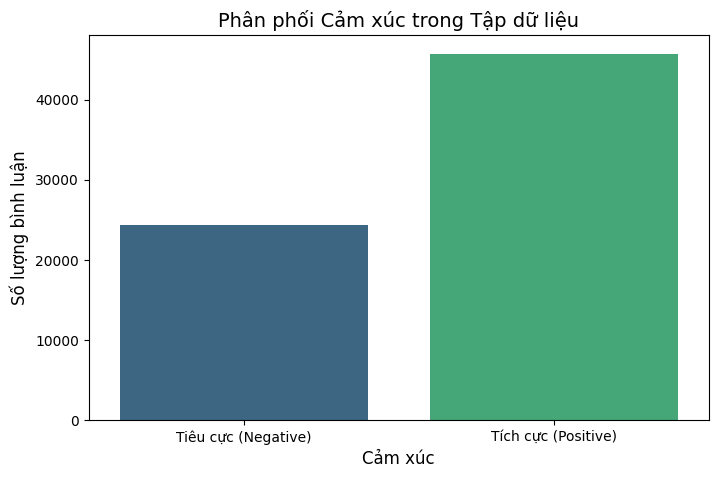

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chuyển thống kê sang Pandas
label_counts = df.groupBy("label").count().toPandas()
label_counts['sentiment'] = label_counts['label'].map({1.0: 'Tích cực (Positive)', 0.0: 'Tiêu cực (Negative)'})

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
sns.barplot(x='sentiment', y='count', data=label_counts, palette='viridis')
plt.title('Phân phối Cảm xúc trong Tập dữ liệu', fontsize=14)
plt.xlabel('Cảm xúc', fontsize=12)
plt.ylabel('Số lượng bình luận', fontsize=12)
plt.show()

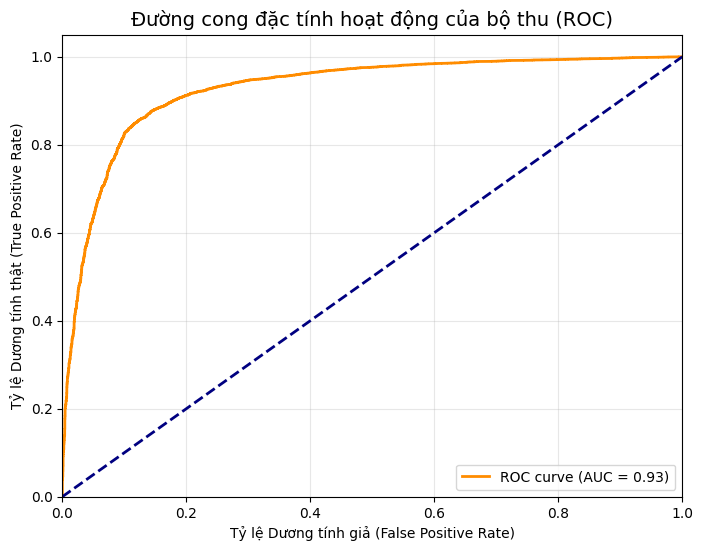

In [16]:
from sklearn.metrics import roc_curve, auc

# Trích xuất xác suất (probability) và nhãn thực tế (label)
# Cột 'probability' trong Spark ML là một Vector [prob_0, prob_1]
preds_pd = test_predictions.select("label", "probability").toPandas()
preds_pd['prob_positive'] = preds_pd['probability'].apply(lambda x: x[1])

fpr, tpr, thresholds = roc_curve(preds_pd['label'], preds_pd['prob_positive'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
plt.title('Đường cong đặc tính hoạt động của bộ thu (ROC)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

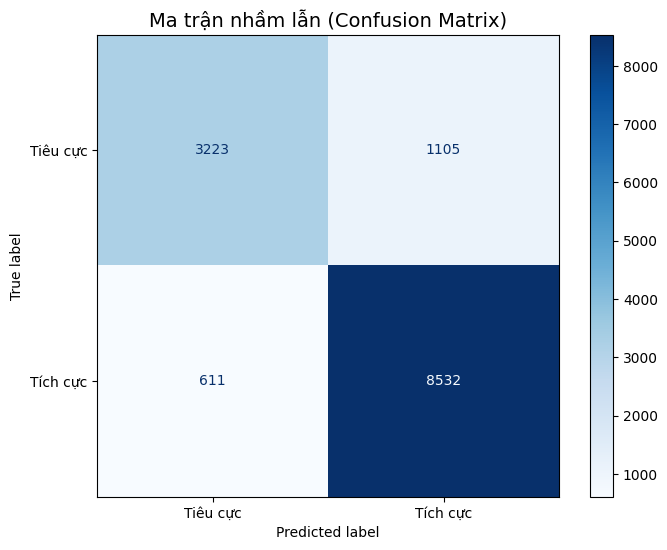

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = preds_pd['label']
y_pred = test_predictions.select("prediction").toPandas()['prediction']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tiêu cực', 'Tích cực'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14)
plt.show()

C:\Users\duyan\AppData\Local\Temp\ipykernel_26160\532941621.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='word', data=top_pos, palette='Greens_r')
C:\Users\duyan\AppData\Local\Temp\ipykernel_26160\532941621.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='word', data=top_neg, palette='Reds')


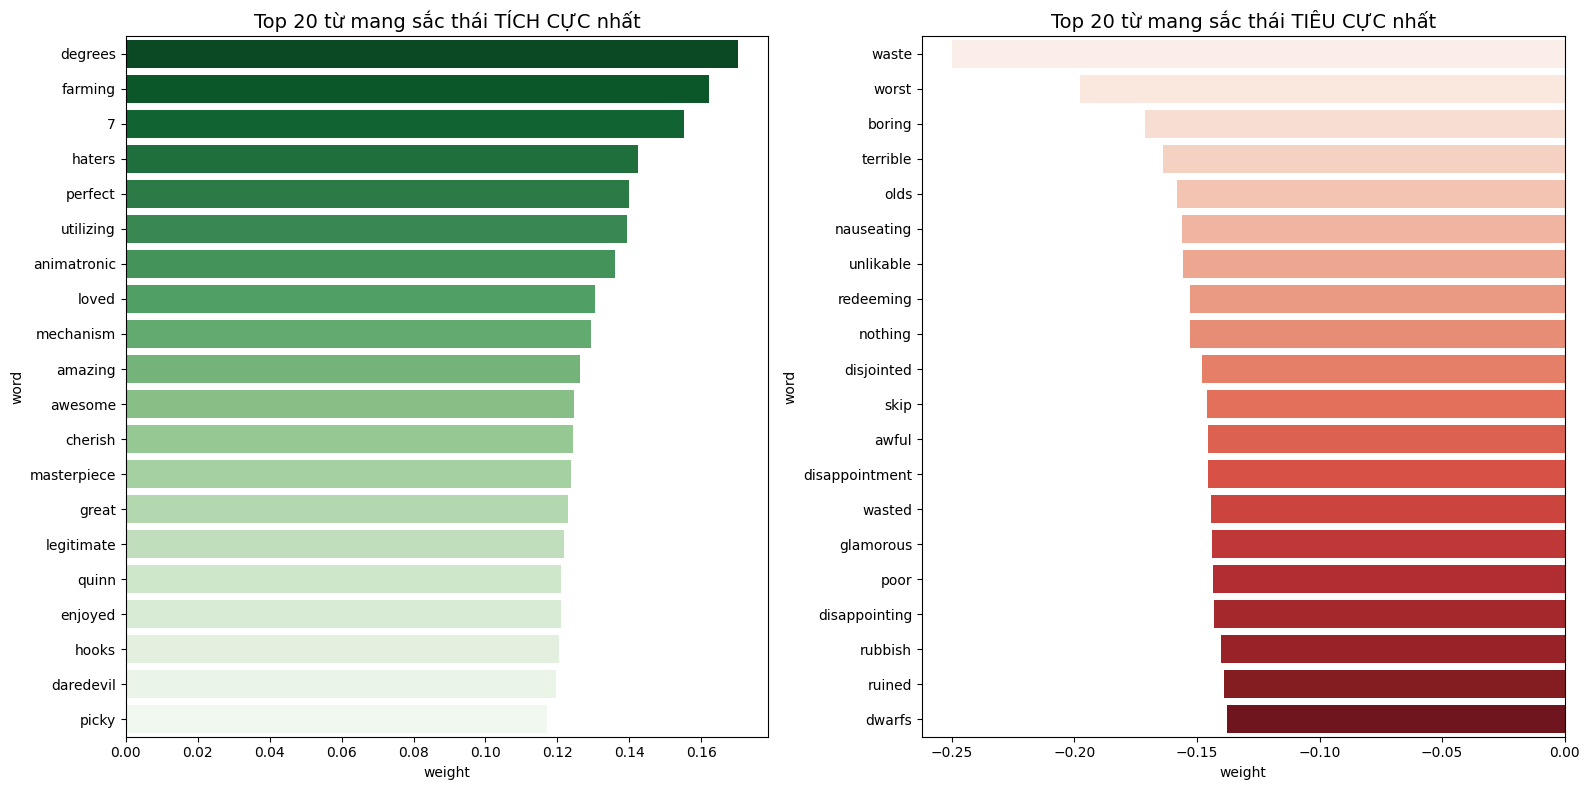

In [18]:
import pandas as pd

# Lấy Vocabulary từ CountVectorizer (Stage 2) và Hệ số từ LogisticRegression (Stage 4)
cv_model = model.stages[2]
lr_model = model.stages[4]

vocab = cv_model.vocabulary
weights = lr_model.coefficients.toArray()

# Tạo DataFrame chứa từ và trọng số tương ứng
coeffs_df = pd.DataFrame({'word': vocab, 'weight': weights})

# Lấy Top 20 từ Tích cực nhất và Top 20 từ Tiêu cực nhất
top_pos = coeffs_df.sort_values(by='weight', ascending=False).head(20)
top_neg = coeffs_df.sort_values(by='weight', ascending=True).head(20)

# Vẽ biểu đồ
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.barplot(x='weight', y='word', data=top_pos, palette='Greens_r')
plt.title('Top 20 từ mang sắc thái TÍCH CỰC nhất', fontsize=14)

plt.subplot(1, 2, 2)
sns.barplot(x='weight', y='word', data=top_neg, palette='Reds')
plt.title('Top 20 từ mang sắc thái TIÊU CỰC nhất', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
print("BẮT ĐẦU DÙNG AI CHẤM ĐIỂM CHO TOÀN BỘ DỮ LIỆU...")
# all_predictions được tạo ra bằng cách ném TOÀN BỘ clean_df vào model đã train
# Lưu ý: clean_df bao gồm cả 2275 dòng bị NULL rating
all_predictions = model.transform(clean_df)

# Kiểm tra thử kết quả dự đoán của 2275 dòng NULL đó
print("Kết quả AI dự đoán cho những dòng vốn bị NULL rating:")
all_predictions.filter(F.col("rating").isNull()) \
               .select("content", "prediction", "probability") \
               .show(5, truncate=False)




BẮT ĐẦU DÙNG AI CHẤM ĐIỂM CHO TOÀN BỘ DỮ LIỆU...
Kết quả AI dự đoán cho những dòng vốn bị NULL rating:
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# Bước cuối: Chọn các cột cần thiết để lưu trữ
final_df = all_predictions.select(
    "review_id",
    "imdb_id",
    "content",
    "rating",
    "source_system"
)
output_path = "nlp/reviews_enriched"
write_data_to_minio(final_df.coalesce(1), bucket_name, output_path, target_date)

[*] Đang ghi dữ liệu (70076 dòng) xuống: s3a://silver/nlp/reviews_enriched/2026/03/30/
[*] Tự động điều chỉnh: 70076 dòng -> 4 partitions
[*] Đang ghi dữ liệu (70076 dòng) xuống: s3a://silver/nlp/reviews_enriched/2026/03/30/
[*] Ghi dữ liệu thành công!
